![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [102]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn import metrics
import matplotlib.patches as mpatches

In [103]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Definición de 4 modelos diferentes: regresión logística, árbol de decisión,Navie Bayes y k vecinos más cercanos
models = {'lr': LinearRegression(),
          'dt': DecisionTreeRegressor(),
          'nb': GaussianNB(),
          'kn': KNeighborsRegressor()}

In [104]:
# Importación de librerías
%matplotlib inline
import pandas as pd


# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [105]:
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

## Pequeña Exploración

In [106]:
# Identificación de valores faltantes
valores_faltantes = data.isnull().sum()
print(valores_faltantes)

Price          0
Year           0
Mileage        0
M_Camry        0
M_Camry4dr     0
M_CamryBase    0
M_CamryL       0
M_CamryLE      0
M_CamrySE      0
M_CamryXLE     0
dtype: int64


In [107]:
# Estadisticas descriptivas
data.describe()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
count,10495.000000,10495.000000,10495.000000,10495.000000,10495.000000,10495.000000,10495.000000,10495.000000,10495.000000,10495.000000
mean,14538.403716,2013.553883,52509.430395,0.056313,0.158456,0.012292,0.048213,0.236494,0.376370,0.111863
std,3922.420961,3.116585,36791.736601,0.230535,0.365186,0.110189,0.214227,0.424949,0.484498,0.315213
min,5002.000000,1998.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11999.000000,2012.000000,26461.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,15000.000000,2014.000000,41680.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,16999.000000,2016.000000,71355.500000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,32444.000000,2018.000000,232658.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


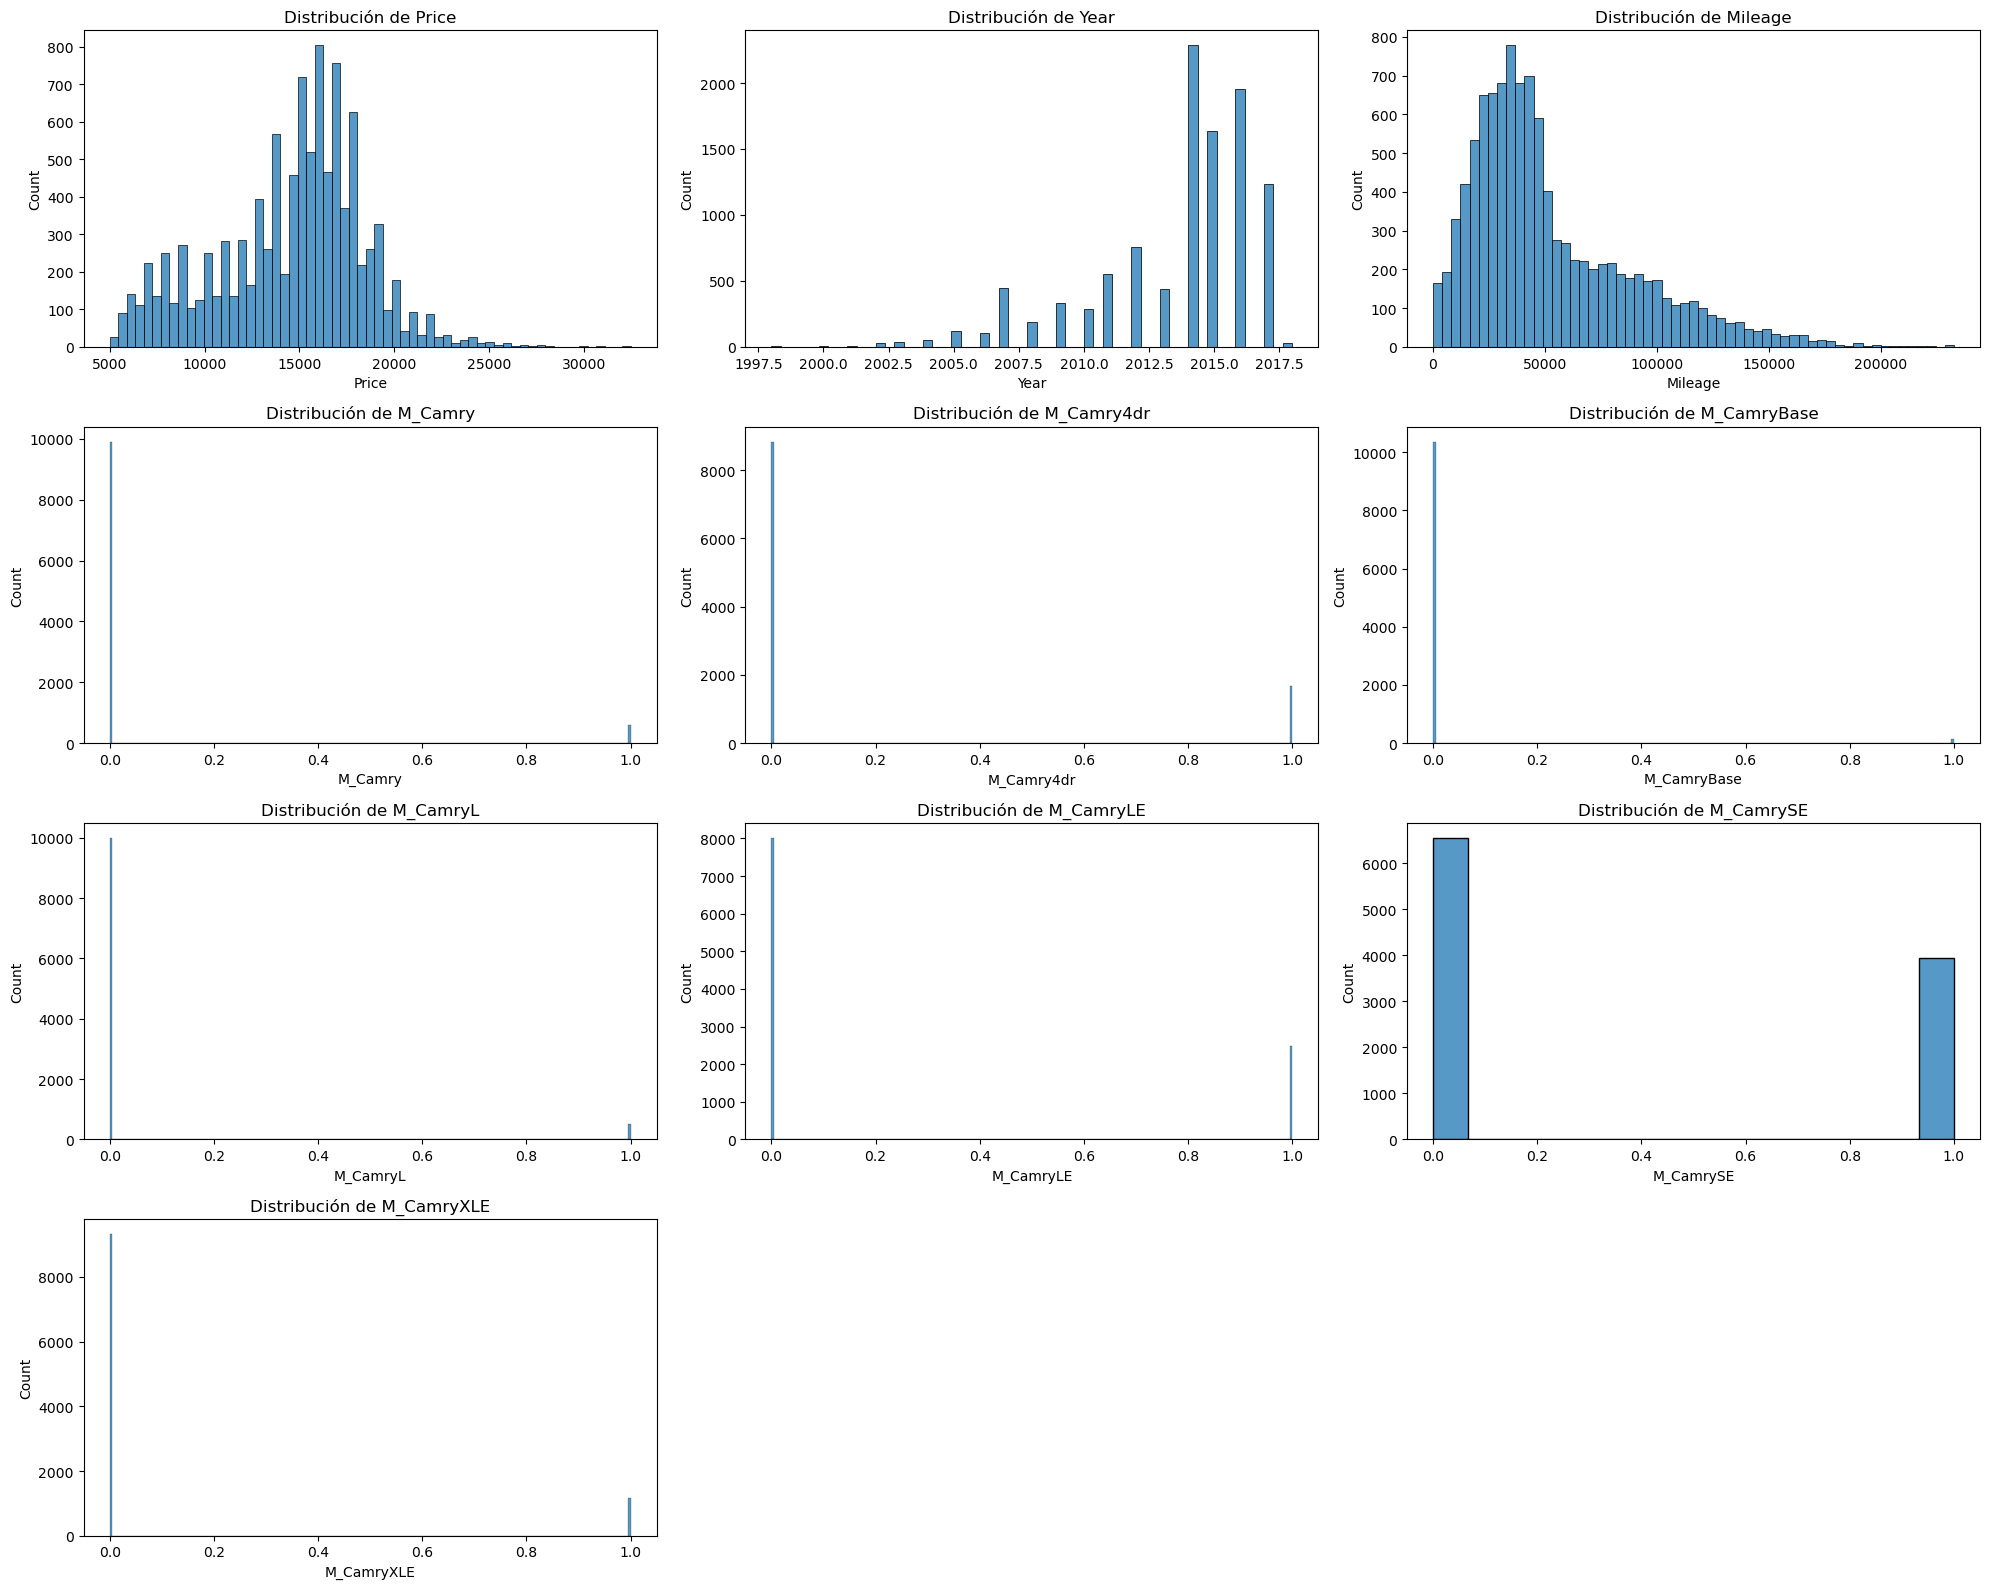

In [108]:
cols = data.columns
n_cols = 3  
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten() 

for i, col in enumerate(cols):
    sns.histplot(data=data, x=col, ax=axes[i]) 
    axes[i].set_title(f'Distribución de {col}')

# Eliminar ejes vacíos si el total de variables no es múltiplo de n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

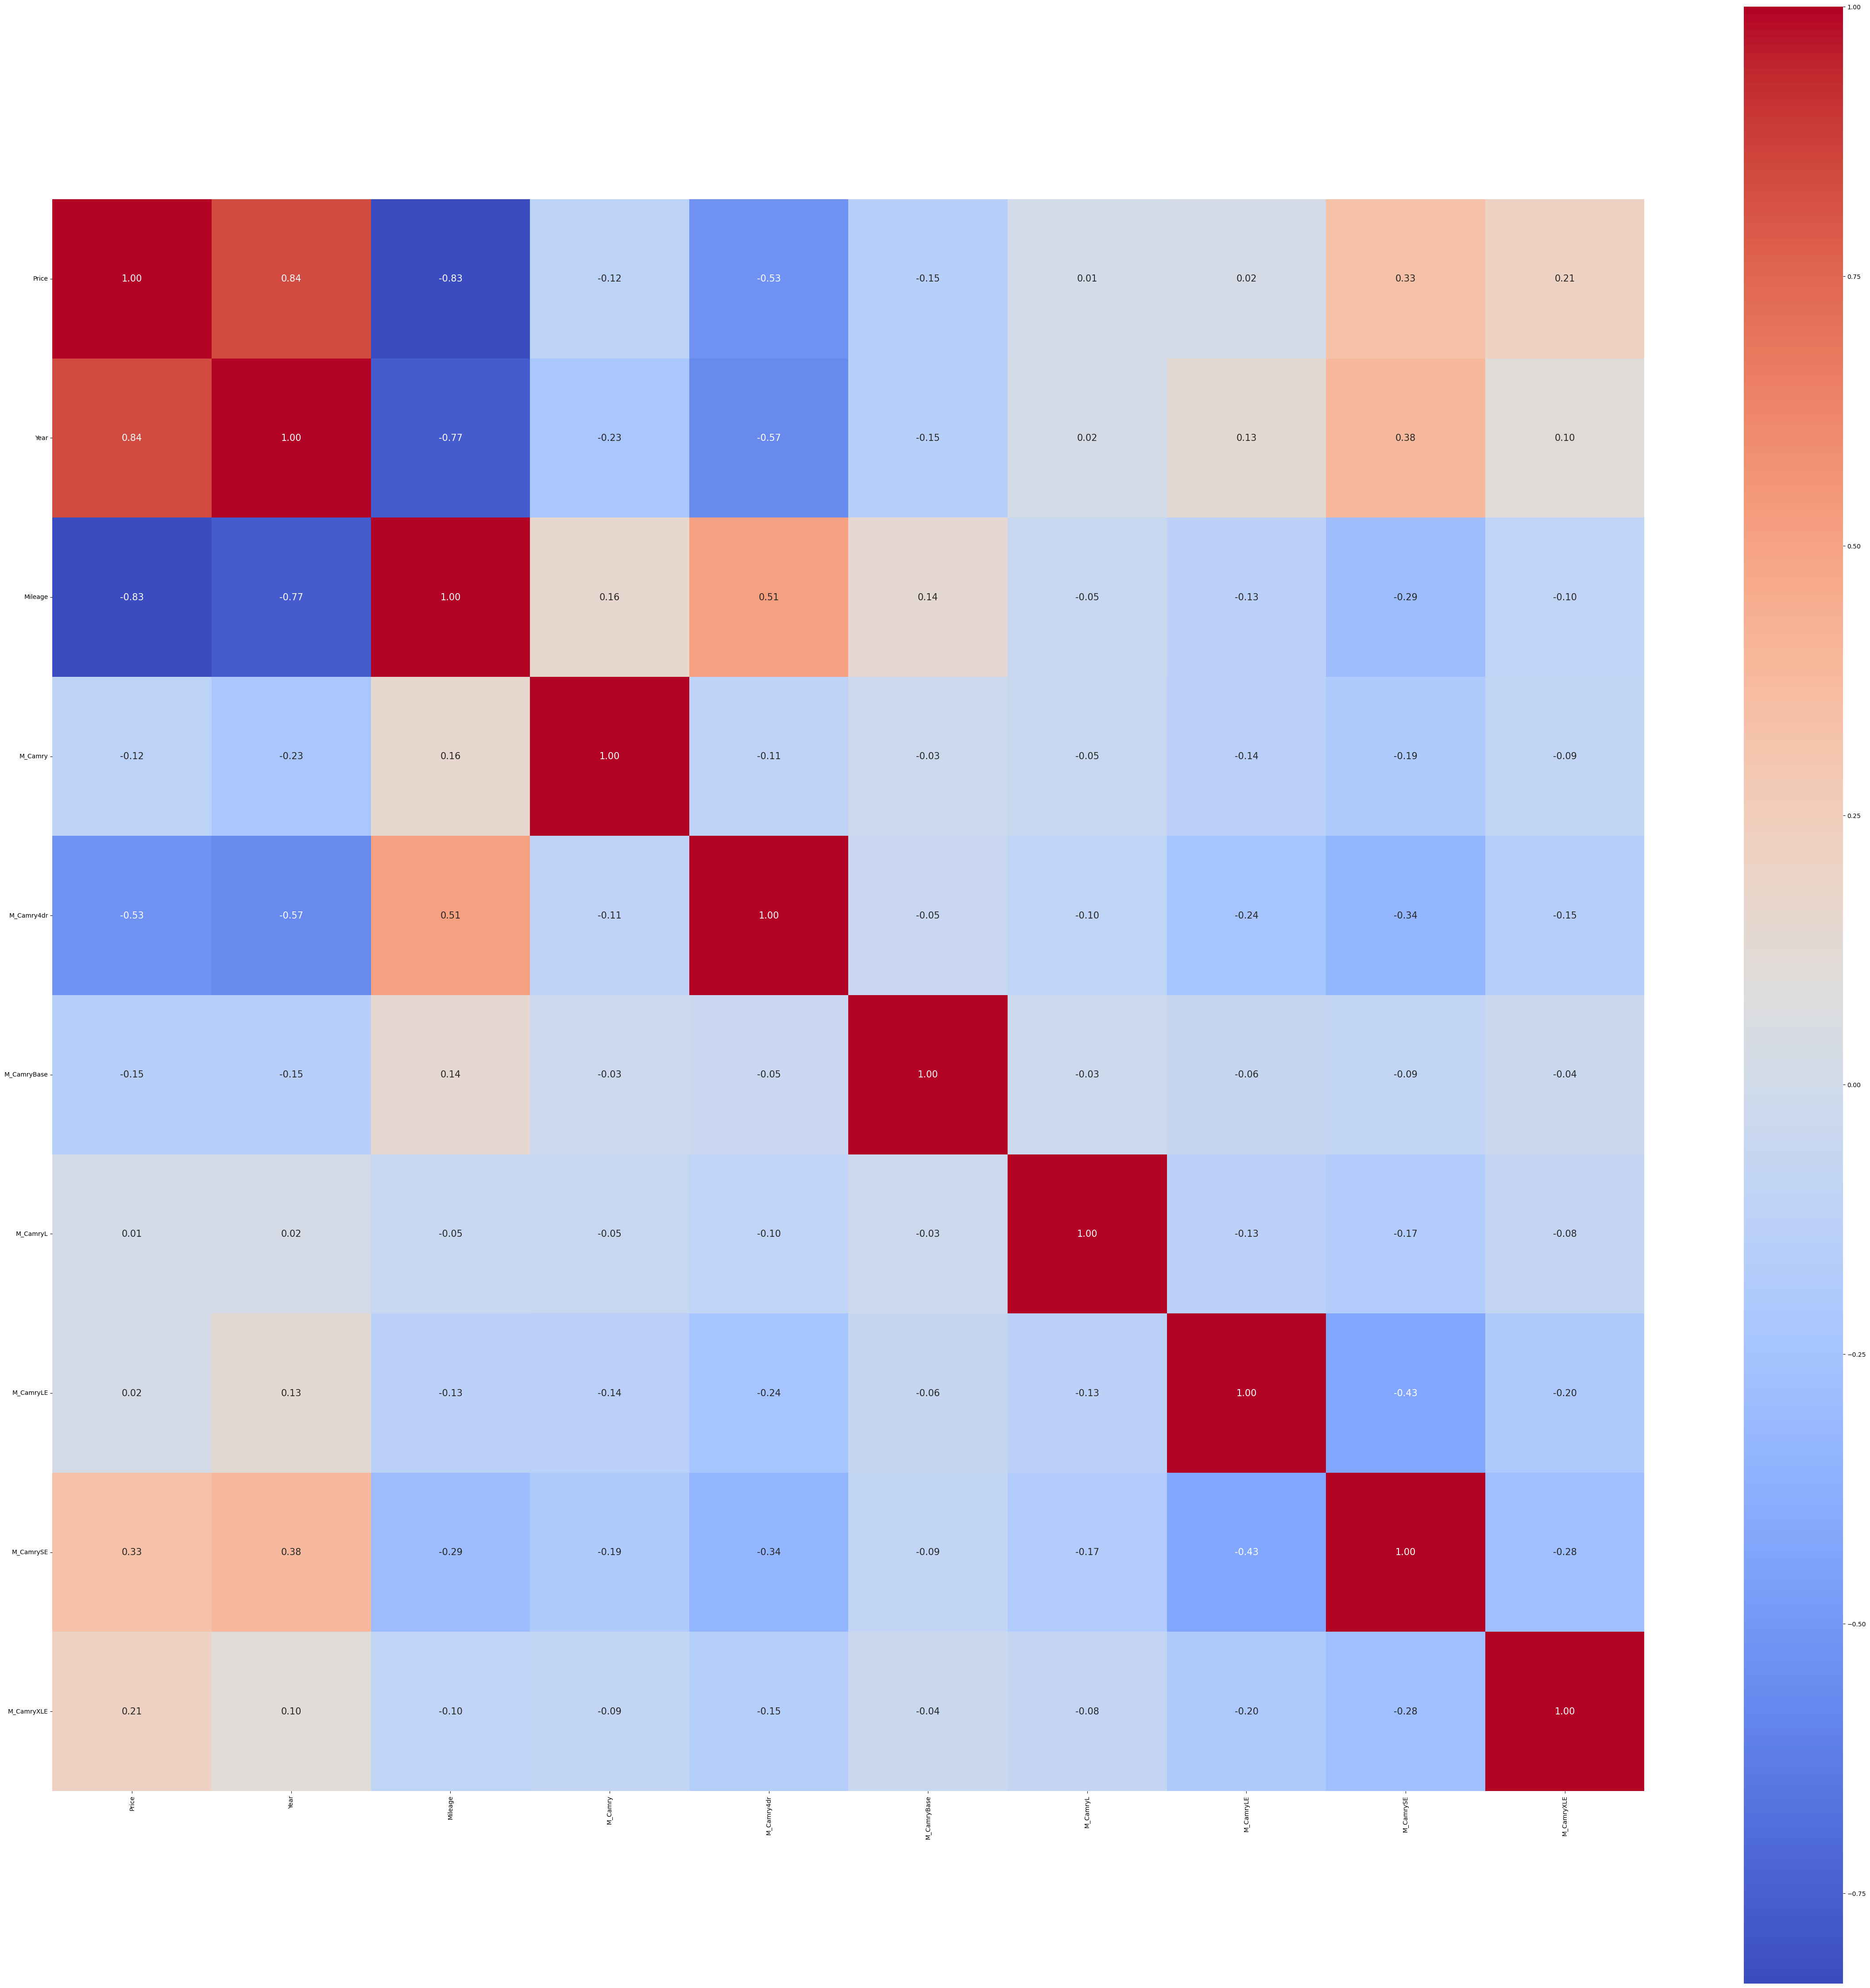

In [109]:
#Correlaciones
corr = data.corr()
plt.figure(figsize=(58,58))
sns.heatmap(corr, cbar = True,  square = True, annot=True, fmt= '.2f',annot_kws={'size': 15}, cmap= 'coolwarm')
plt.xticks(rotation = 90)
plt.yticks(rotation = 0)
plt.show()

## Comentarios de la Exploración

El dataset tiene 10.495 registros sin valores faltantes. 
El target esta entre $5.002 y $32.444 con media de $14.538, tiene una distribución aproximadamente normal, concentrada entre $10.000 y $20.000.
La variable Year, la mayor parte de los autos esta entre 2013 y 2017 con sesgo hacia años recientes.
La variable Mileage, con sesgo a la derecha, la mayoría con bajo kilometraje, algunos outliers extremos, alrededor de 230k.

Para las otras variables M_CamrySE es el trim más frecuente, media=0.37; 

M_CamryBase y M_CamryL son muy raros, media < 0.05

#### Correlaciones con Price

**Year:** tiene una correlación de +0.84, es decir, entre más nuevo más caro

**Mileage:** tiene una correlación negativa de -0.83, más kilometraje más barato

**M_CamrySE:** tiene una correlación de +0.33 SE vale más

**M_Camry4dr:** tiene una correlación negativa -0.53 con el precio

In [110]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [111]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [112]:
# Celda 1
X_tr = X_train.reset_index(drop=True).copy()
X_ts = X_test.reset_index(drop=True).copy()
y_tr = y_train.reset_index(drop=True).copy()
y_ts = y_test.reset_index(drop=True).copy()

X_tr = X_tr.astype(float)
X_ts = X_ts.astype(float)
y_tr = y_tr.astype(float)
y_ts = y_ts.astype(float)

# Parámetros del árbol
max_depth = 3
num_pct = 10
min_gain = 1e-6

# Función de impureza para regresión: varianza / SSE implícita
def variance(y):
    if y.shape[0] == 0:
        return 0
    return np.var(y)

# Reducción de impureza para una variable predictora X_col y un punto de corte
def variance_reduction(X_col, y, split):
    
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    
    n = y.shape[0]
    n_l = y_l.shape[0]
    n_r = y_r.shape[0]
    
    if n_l == 0 or n_r == 0:
        return -np.inf
    
    var_y = variance(y)
    var_l = variance(y_l)
    var_r = variance(y_r)
    
    reduction = var_y - (n_l / n) * var_l - (n_r / n) * var_r
    
    return reduction

# Función best_split para encontrar la mejor variable y el mejor punto de corte
def best_split(X, y, num_pct=10):
    
    features = range(X.shape[1])
    best_split = [0, 0, -np.inf]   # j, split, gain
    
    for j in features:
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct + 1)).tolist())
        splits = np.unique(splits)[1:]
        
        for split in splits:
            gain = variance_reduction(X.iloc[:, j], y, split)
            
            if gain > best_split[2]:
                best_split = [j, split, gain]
    
    return best_split


# Crecimiento recursivo del árbol manual para regresión
def tree_grow(X, y, level=0, min_gain=1e-6, max_depth=None, num_pct=10):
    
    # Si solo hay una observación
    if X.shape[0] == 1:
        tree = dict(y_pred=float(y.iloc[0]), 
                    y_mean=float(y.iloc[0]),
                    level=level, 
                    split=-1, 
                    n_samples=1, 
                    gain=0)
        return tree
    
    # Hallar mejor división
    j, split, gain = best_split(X, y, num_pct)
    
    # Guardar información del nodo
    y_pred = float(y.mean())
    tree = dict(y_pred=y_pred, 
                y_mean=float(y.mean()),
                level=level, 
                split=-1, 
                n_samples=X.shape[0], 
                gain=float(gain))
    
    # Criterios de parada
    if gain < min_gain:
        return tree
    
    if max_depth is not None:
        if level >= max_depth:
            return tree
    
    # Aplicar partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    
    # Si alguna rama queda vacía, detener
    if X_l.shape[0] == 0 or X_r.shape[0] == 0:
        return tree
    
    # Guardar split
    tree['split'] = [j, float(split)]
    
    # Recursión
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree

# Función de predicción con el árbol manual
def tree_predict(X, tree):
    
    predicted = np.zeros(X.shape[0], dtype=float)
    
    # Nodo terminal
    if tree['split'] == -1:
        predicted = predicted + tree['y_pred']
    
    else:
        j, split = tree['split']
        filter_l = X.iloc[:, j] < split
        X_l = X.loc[filter_l]
        X_r = X.loc[~filter_l]
        
        if X_l.shape[0] == 0:
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])
        
        elif X_r.shape[0] == 0:
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
        
        else:
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])
    
    return predicted

# Entrenamiento del árbol
tree = tree_grow(X_tr, y_tr, level=0, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)

# Predicción en test
y_pred_test = tree_predict(X_ts, tree)

# Métricas de evaluación
rmse_tm = np.sqrt(mean_squared_error(y_ts, y_pred_test))
mae_tm = mean_absolute_error(y_ts, y_pred_test)
mse_tm  = mean_squared_error(y_ts, y_pred_test)
r2_tm   = r2_score(y_ts, y_pred_test)


print("Resultados árbol de decisión manual")
print(f"RMSE en test: {rmse_tm:.4f}")
print(f"MAE en test : {mae_tm:.4f}")
print(f"MSE en test : {mse_tm:.4f}")
print(f"R² en test  : {r2_tm:.4f}")


Resultados árbol de decisión manual
RMSE en test: 1921.0003
MAE en test : 1445.8091
MSE en test : 3690242.2628
R² en test  : 0.7587


**Procedimiento**  
Se implementó manualmente un árbol de decisión para regresión, donde en cada nodo se evaluaron distintas variables predictoras y múltiples puntos de corte candidatos obtenidos a partir de percentiles. Para cada posible partición se calculó la reducción de varianza, y se seleccionó aquella combinación variable-corte que maximizó la disminución de la heterogeneidad de la variable respuesta. El crecimiento del árbol se controló mediante los parámetros max_depth, num_pct y min_gain, con el fin de limitar la complejidad del modelo y evitar particiones poco informativas, y en cada nodo terminal la predicción se estableció como el valor promedio del precio de los automóviles contenidos en dicha hoja. Finalmente, el modelo se evaluó sobre el set de prueba, obteniendo un RMSE de 1921.0003 y un MAE de 1445.8091 en el set de prueba.

**Conclusión**  
El árbol de decisión manual logró capturar patrones relevantes entre las variables predictoras y el precio de los automóviles, especialmente a través de variables como el año y el kilometraje. No obstante, los valores de RMSE y MAE evidencian que aún existen errores de predicción considerables en el set de prueba. En consecuencia, este modelo constituye una base conceptual adecuada, pero también sugiere la conveniencia de evaluar métodos de ensamble como bagging, random forest y XGBoost, que podrían mejorar la capacidad predictiva en este problema.

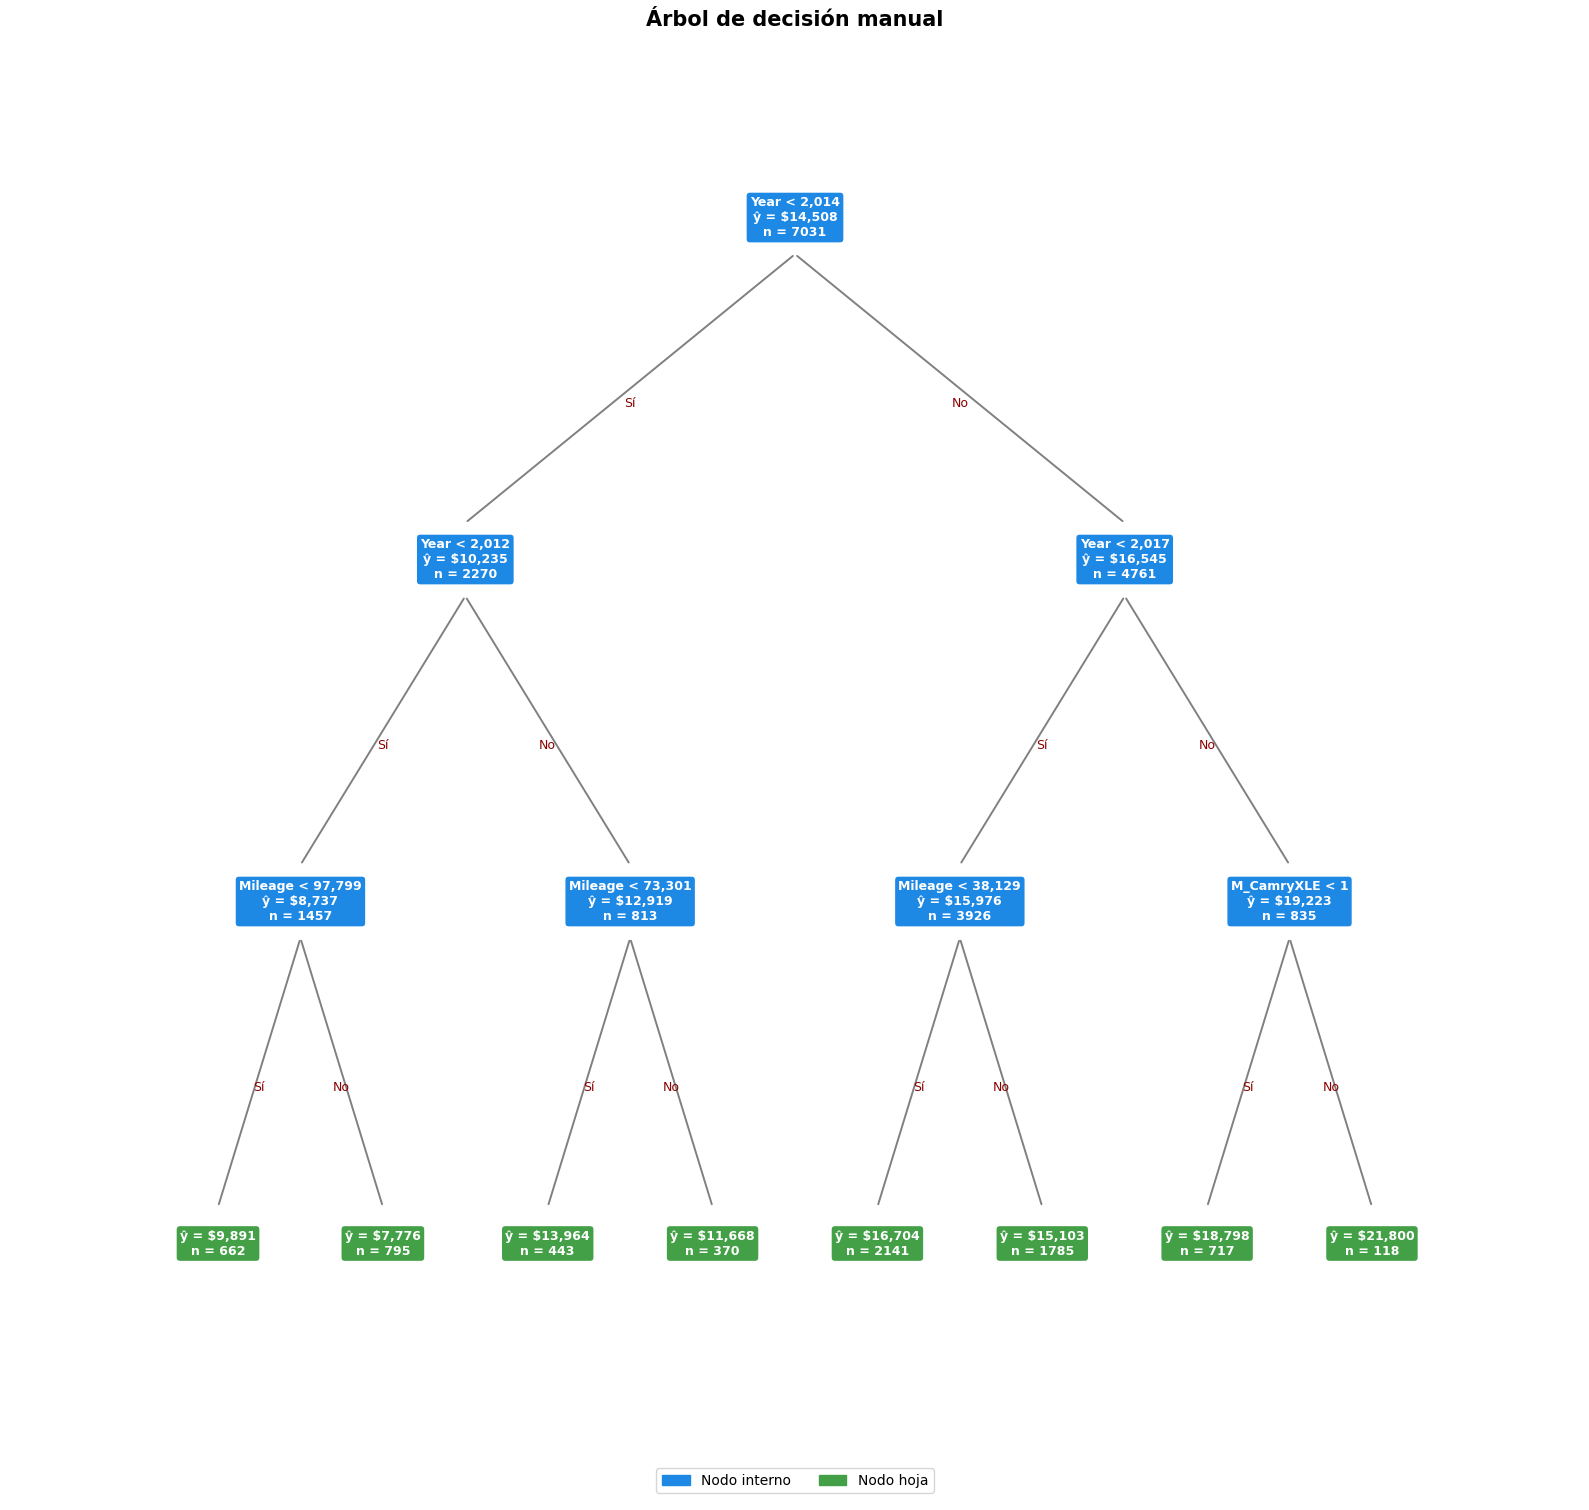

In [113]:
# =========================
# Visualización del árbol
# =========================

# Nombres de variables
feature_names = X_tr.columns.tolist()

# Profundidad del árbol
def tree_depth(tree):
    if tree['split'] == -1:
        return 0
    return 1 + max(tree_depth(tree['sl']), tree_depth(tree['sr']))

# Dibujar árbol
def plot_tree_manual(ax, tree, x, y, dx, dy, feature_names, parent=None, side=None):
    is_leaf = tree['split'] == -1
    color = '#43A047' if is_leaf else '#1E88E5'
    
    # Texto del nodo
    if is_leaf:
        text = f"ŷ = ${tree['y_pred']:,.0f}\nn = {tree['n_samples']}"
    else:
        j, split = tree['split']
        text = (
            f"{feature_names[j]} < {split:,.0f}\n"
            f"ŷ = ${tree['y_pred']:,.0f}\n"
            f"n = {tree['n_samples']}"
        )

    # Flecha desde el padre
    if parent is not None:
        ax.annotate(
            "",
            xy=(x, y + 0.03),
            xytext=parent,
            arrowprops=dict(arrowstyle='-', lw=1.4, color='gray')
        )
        if side is not None:
            ax.text(
                (x + parent[0]) / 2,
                (y + parent[1]) / 2,
                side,
                fontsize=9,
                color='darkred',
                ha='center'
            )

    # Caja del nodo
    ax.text(
        x, y, text,
        ha='center', va='center',
        fontsize=9,
        color='white',
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.35',
            facecolor=color,
            edgecolor='white',
            linewidth=1.5
        )
    )

    # Recursión
    if not is_leaf:
        plot_tree_manual(ax, tree['sl'], x - dx, y - dy, dx / 2, dy,
                         feature_names, parent=(x, y - 0.03), side='Sí')
        plot_tree_manual(ax, tree['sr'], x + dx, y - dy, dx / 2, dy,
                         feature_names, parent=(x, y - 0.03), side='No')


# Crear figura
depth = tree_depth(tree)
fig, ax = plt.subplots(figsize=(16, 3.8 * (depth + 1)))
ax.set_xlim(-1, 1)
ax.set_ylim(-1.05, 0.15)
ax.axis('off')

plot_tree_manual(ax, tree, x=0, y=0, dx=0.42, dy=0.28, feature_names=feature_names)

# Leyenda
internal_patch = mpatches.Patch(color='#1E88E5', label='Nodo interno')
leaf_patch = mpatches.Patch(color='#43A047', label='Nodo hoja')
ax.legend(handles=[internal_patch, leaf_patch], loc='lower center', ncol=2, fontsize=10)

ax.set_title("Árbol de decisión manual", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Visualización del árbol**  
Como apoyo a la interpretación del modelo, se presenta la estructura del árbol de decisión construido manualmente. En los nodos internos se muestra la variable seleccionada, el punto de corte, la predicción promedio del nodo y el número de observaciones, mientras que en los nodos hoja se reporta la predicción final y el tamaño de la hoja. Esta visualización permite identificar de forma clara las particiones más relevantes del modelo para la predicción del precio de los automóviles.

### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [114]:
# Celda 2
# =========================
# Bagging manual con 10 árboles de regresión
# =========================

np.random.seed(123)

n_b = 10
n_samples = X_tr.shape[0]

# DataFrame para guardar predicciones de cada árbol sobre test
y_pred_bag = pd.DataFrame(index=X_ts.index, columns=range(n_b), dtype=float)

# Lista para guardar los árboles construidos
bagging_trees = []

# Construcción manual del bagging
for b in range(n_b):
    
    # 1. Muestra bootstrap
    sample_idx = np.random.choice(a=n_samples, size=n_samples, replace=True)
    X_boot = X_tr.iloc[sample_idx].reset_index(drop=True)
    y_boot = y_tr.iloc[sample_idx].reset_index(drop=True)
    
    # 2. Entrenamiento de un árbol manual sobre la muestra bootstrap
    tree_b = tree_grow(
        X_boot, y_boot,
        level=0,
        min_gain=min_gain,
        max_depth=max_depth,
        num_pct=num_pct
    )
    
    # 3. Guardar árbol
    bagging_trees.append(tree_b)
    
    # 4. Predicción sobre el set de test
    y_pred_bag.iloc[:, b] = tree_predict(X_ts, tree_b)

# =========================
# Desempeño individual de cada árbol
# =========================
print("Desempeño individual de los árboles:")
for b in range(n_b):
    rmse_b = np.sqrt(mean_squared_error(y_ts, y_pred_bag.iloc[:, b]))
    mae_b = mean_absolute_error(y_ts, y_pred_bag.iloc[:, b])
    print(f"Árbol {b+1:02d} -> RMSE: {rmse_b:.4f} | MAE: {mae_b:.4f}")

# =========================
# Predicción final del bagging
# =========================
y_pred_bagging = y_pred_bag.mean(axis=1)

# =========================
# Métricas finales del bagging
# =========================
rmse_bagging = np.sqrt(mean_squared_error(y_ts, y_pred_bagging))
mae_bagging = mean_absolute_error(y_ts, y_pred_bagging)
mse_bagging  = mean_squared_error(y_ts, y_pred_bagging)
r2_bagging   = r2_score(y_ts, y_pred_bagging)

print("\nResultados bagging manual")
print(f"RMSE en test: {rmse_bagging:.4f}")
print(f"MAE en test : {mae_bagging:.4f}")
print(f"MSE en test : {mse_bagging:.4f}")
print(f"R² en test  : {r2_bagging:.4f}")

Desempeño individual de los árboles:
Árbol 01 -> RMSE: 1939.5424 | MAE: 1466.5252
Árbol 02 -> RMSE: 1925.4696 | MAE: 1442.4803
Árbol 03 -> RMSE: 1925.9327 | MAE: 1450.2046
Árbol 04 -> RMSE: 1931.9761 | MAE: 1453.7045
Árbol 05 -> RMSE: 1927.5260 | MAE: 1444.9691
Árbol 06 -> RMSE: 1930.6948 | MAE: 1456.4337
Árbol 07 -> RMSE: 1901.3421 | MAE: 1424.8493
Árbol 08 -> RMSE: 1909.0280 | MAE: 1440.2191
Árbol 09 -> RMSE: 1945.9590 | MAE: 1469.0218
Árbol 10 -> RMSE: 1923.4449 | MAE: 1446.7780

Resultados bagging manual
RMSE en test: 1832.6460
MAE en test : 1376.3909
MSE en test : 3358591.3132
R² en test  : 0.7804


**Procedimiento**  
Se implementó manualmente un modelo de bagging para regresión con 10 árboles. Para ello, se generaron 10 muestras bootstrap a partir del set de entrenamiento y sobre cada una se ajustó un árbol de decisión utilizando la función construida en el punto anterior. Luego, cada árbol realizó predicciones sobre el set de prueba y la predicción final del ensamble se obtuvo como el promedio de las predicciones individuales. Finalmente, el desempeño del modelo se evaluó mediante las métricas RMSE y MAE en el set de prueba.

**Comentario de resultados**  
Los errores individuales de los árboles fueron relativamente cercanos entre sí, con valores de RMSE alrededor de 1900 y MAE alrededor de 1450. Sin embargo, al promediar sus predicciones, el modelo de bagging obtuvo un **RMSE de 1832.6460** y un **MAE de 1376.3909**, mejorando el desempeño frente al árbol de decisión manual del punto anterior. Esto indica que el ensamble logra predicciones más estables y con menor error, al compensar parcialmente las variaciones de cada árbol individual.

**Conclusión**  
El bagging manual mostró un mejor desempeño que el árbol de decisión individual, al reducir tanto el RMSE como el MAE en el set de prueba. Este resultado confirma que combinar múltiples árboles entrenados sobre muestras bootstrap permite disminuir la variabilidad del modelo y mejorar su capacidad predictiva. En este caso, el bagging constituye una alternativa más robusta que un único árbol para predecir el precio de los automóviles.

### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [115]:
# Celda 3
# Uso de BaggingRegressor de la libreria (sklearn) donde se usa el modelo DecisionTreeRegressor como estimador
from sklearn.ensemble import BaggingRegressor
bagreg = BaggingRegressor(DecisionTreeRegressor(max_features='log2'), n_estimators=10, 
                          bootstrap=True, oob_score=True, random_state=1)

# Entrenemiento del modelo con set de entrenamiento y predicción en el set de test
bagreg.fit(X_train, y_train)
y_pred_b = bagreg.predict(X_test)
y_pred_b

# Cálculo del error del modelo
np.sqrt(mean_squared_error(y_test, y_pred_b))

# Métricas principales
mse_b  = mean_squared_error(y_test, y_pred_b)
rmse_b = np.sqrt(mse_b)
mae_b  = mean_absolute_error(y_test, y_pred_b)
r2_b   = r2_score(y_test, y_pred_b)
oob_b  = bagreg.oob_score_

print(f"MSE:  {mse_b:.4f}")
print(f"RMSE: {rmse_b:.4f}")   
print(f"MAE:  {mae_b:.4f}")    
print(f"R²:   {r2_b:.4f}")     
print(f"OOB R²: {oob_b:.4f}")  

MSE:  3329530.1154
RMSE: 1824.7000
MAE:  1361.8777
R²:   0.7823
OOB R²: 0.6078


El modelo de Bagging con 10 árboles alcanza un R2 de 0.78 en test, lo que indica una capacidad predictiva aceptable. Sin embargo, la brecha entre el OOB R2 (0.61) y el R2 test sugiere que con solo 10 estimadores la estimación OOB es inestable. Aumentar el número de árboles debería cerrar esa brecha y potencialmente mejorar el desempeño general.

### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

In [ ]:
# Celda 4
rf = RandomForestRegressor(oob_score=True, random_state=1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf

# Evaluación
mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"RMSE: {rmse_rf:.4f}")
print(f"R2:   {r2_rf:.4f}")
print(f"OOB R2: {rf.oob_score_}")  
print(f"MAE:  {mae_rf:.4f}")  

RMSE: 1755.8728
R²:   0.7984
OOB R²: 0.8009402751337424
MAE:  1307.0800


El modelo Random Forest con parámetros por defecto alcanza un R2 de 0.80, explicando el 80% de la varianza del target. La cercanía entre OOB R2 (0.8009) y Test R2 (0.7984); una diferencia de apenas 0.0025; confirma que el modelo generaliza bien sin sobreajuste. Comparado con el Bagging de 10 árboles (R2 = 0.7823, brecha OOB-Test = 0.17), Random Forest mejora tanto en precisión como en estabilidad, gracias a la decorrelación forzada entre árboles y al mayor número de estimadores por defecto (100).

### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

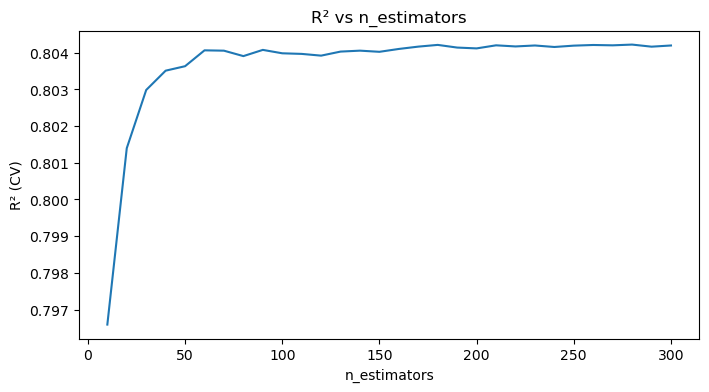

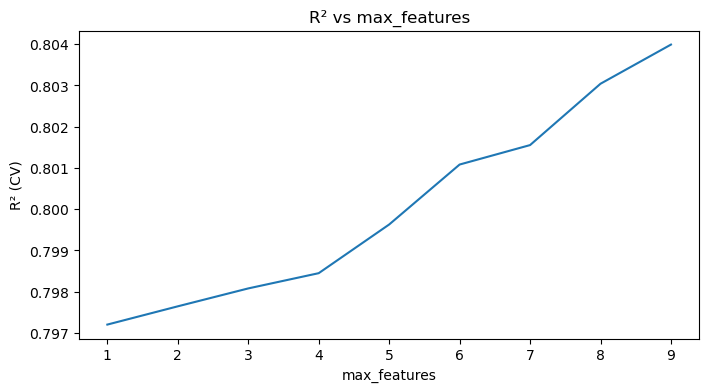

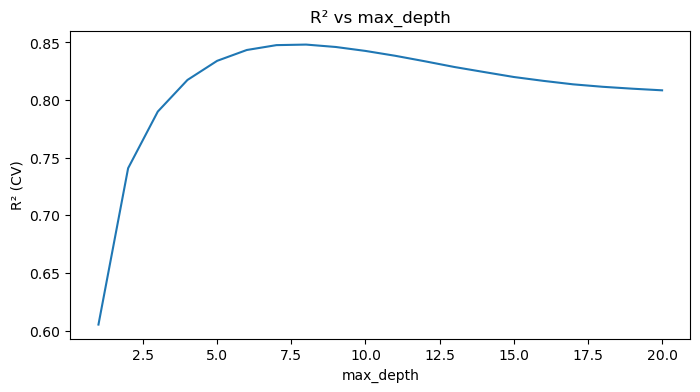

In [117]:
# Celda 5

# n_estimators
estimator_range = range(10, 310, 10)
r2_estimators = []

for n in estimator_range:
    rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
    r2_estimators.append(cross_val_score(rf, X_train, y_train, cv=5, scoring='r2').mean())

plt.figure(figsize=(8, 4))
plt.plot(estimator_range, r2_estimators)
plt.xlabel('n_estimators')
plt.ylabel('R² (CV)')
plt.title('R² vs n_estimators')
plt.show()

# max_feautures
feature_range = range(1, X_train.shape[1] + 1)
r2_features = []

for f in feature_range:
    rf = RandomForestRegressor(max_features=f, random_state=1, n_jobs=-1)
    r2_features.append(cross_val_score(rf, X_train, y_train, cv=5, scoring='r2').mean())

plt.figure(figsize=(8, 4))
plt.plot(feature_range, r2_features)
plt.xlabel('max_features')
plt.ylabel('R² (CV)')
plt.title('R² vs max_features')
plt.show()

# max_depth

depth_range = range(1, 21)
r2_depth = []

for d in depth_range:
    rf = RandomForestRegressor(max_depth=d, random_state=1, n_jobs=-1)
    r2_depth.append(cross_val_score(rf, X_train, y_train, cv=5, scoring='r2').mean())

plt.figure(figsize=(8, 4))
plt.plot(depth_range, r2_depth)
plt.xlabel('max_depth')
plt.ylabel('R² (CV)')
plt.title('R² vs max_depth')
plt.show()


In [118]:
best_n    = estimator_range[r2_estimators.index(max(r2_estimators))]
best_feat = list(feature_range)[r2_features.index(max(r2_features))]
best_depth = list(depth_range)[r2_depth.index(max(r2_depth))]

#Mejores parametros
print(f"Mejor n_estimators: {best_n}")
print(f"Mejor max_features: {best_feat}")
print(f"Mejor max_depth: {best_depth}")

Mejor n_estimators: 280
Mejor max_features: 9
Mejor max_depth: 8


In [119]:
rf_final = RandomForestRegressor(
    n_estimators=best_n,
    max_features=best_feat,
    max_depth=best_depth,
    oob_score=True,
    random_state=1,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)
y_pred_final = rf_final.predict(X_test)

# Evaluación
mse_rf_cal  = mean_squared_error(y_test, y_pred_final)
rmse_rf_cal = np.sqrt(mse_rf_cal)
r2_rf_cal   = r2_score(y_test, y_pred_final)
mae_rf_cal = mean_absolute_error(y_test, y_pred_final)

print(f"RMSE: {rmse_rf_cal:.4f}")
print(f"R2:   {r2_rf_cal:.4f}")
print(f"OOB R2: {rf_final.oob_score_}") 
print(f"MAE:  {mae_rf_cal:.4f}") 


RMSE: 1565.2470
R2:   0.8398
OOB R2: 0.8494823141474556
MAE:  1150.6163


Tras calibrar n_estimators=280, max_features=9 y max_depth=8, el modelo Random Forest mejoró su R² de 0.7984 a 0.8398, explicando ahora el 84% de la varianza del target. El RMSE bajó alrededor de 190 unidades. Limitar max_depth redujo el sobreajuste de los árboles individuales, ajustar max_features mejoró la decorrelación entre ellos, y aumentar n_estimators estabilizó las predicciones del ensamble. La cercanía entre OOB (0.8495) y Test R² (0.8398) confirma que el modelo generaliza correctamente.

Tras calibrar los hiperparámetros mediante curvas de validación cruzada con 5 folds, se obtuvieron los valores óptimos n_estimators=280, max_features=9 y max_depth=8, con los que el modelo Random Forest mejoró su R2 de 0.7984 a 0.8398 y redujo el RMSE en aproximadamente 190 unidades.

El parámetro n_estimators controla el número de árboles del ensamble. A medida que aumenta, el R2 sube y luego se estabiliza, más árboles reducen la varianza del ensamble por el efecto de promediado, pero con rendimientos decrecientes. El valor óptimo de 280 indica que a partir de ese punto agregar más árboles no mejora significativamente el desempeño.

El parámetro max_features define cuántas features se evalúan en cada split. Un valor bajo genera árboles más diversos y decorrelacionados entre sí, lo que mejora el ensamble; un valor muy alto hace que todos los árboles sean similares y se pierda el beneficio del Random Forest sobre el Bagging puro. El valor óptimo de 9 (sobre 9 features totales) sugiere que en este dataset, con tan pocas variables, usar la mayoría de ellas por split es la mejor estrategia.

El parámetro max_depth limita la profundidad máxima de cada árbol. Sin restricción, los árboles crecen hasta memorizar los datos de entrenamiento (sobreajuste). Al fijar max_depth=8 se logra un balance entre capacidad del modelo y generalización, lo que se confirma con la cercanía entre OOB R2=0.8495 y Test R2=0.8398, una diferencia de apenas 0.0097 que indica que el modelo generaliza correctamente sin sobreajustar.

### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [120]:
# Celda 6
# Importación y definición de modelo XGBRegressor

clf = XGBRegressor(random_state=1)
clf

# Entrenamiento (fit) y desempeño del modelo XGBRegressor
clf.fit(X_train, y_train)
y_pred_xgb = clf.predict(X_test)

# Evaluación
mse_xgb  = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)

print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²:   {r2_xgb:.4f}")
print(f"MAE:  {mae_xgb:.4f}")

RMSE: 1605.2355
R²:   0.8315
MAE:  1185.2273


XGBoost con parámetros por defecto alcanza un R² de 0.8315, superando al Random Forest sin calibrar (0.7984) y al Bagging de 10 árboles (0.7823). Sin embargo, queda ligeramente por debajo del Random Forest calibrado (0.8398)

### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

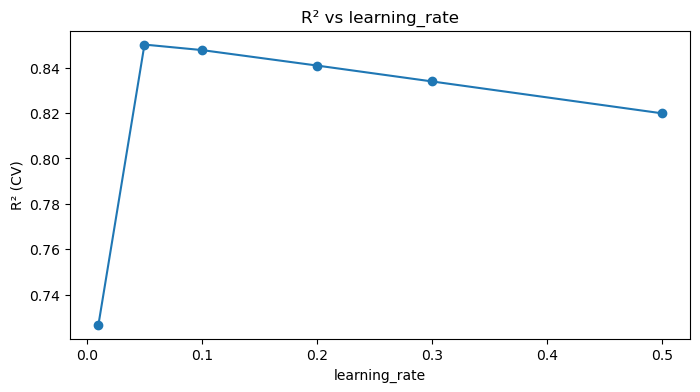

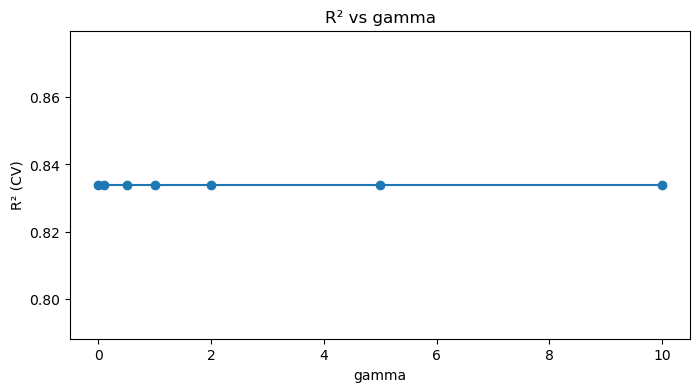

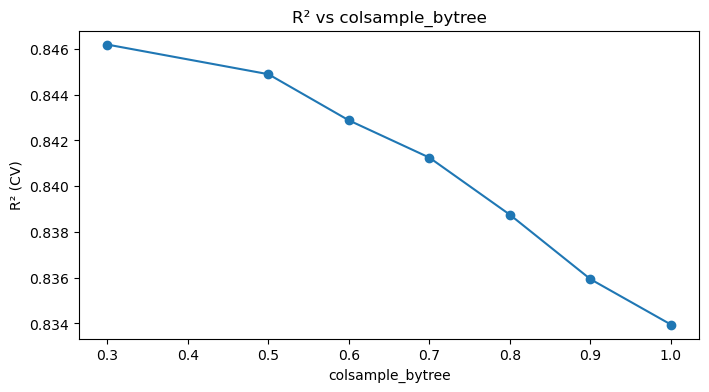

In [121]:
# Celda 7
# learning_rate
lr_range = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
r2_lr = []

for lr in lr_range:
    xgb = XGBRegressor(learning_rate=lr, random_state=1, n_jobs=-1 )
    r2_lr.append(cross_val_score(xgb, X_train, y_train, cv=5, scoring='r2').mean())

plt.figure(figsize=(8, 4))
plt.plot(lr_range, r2_lr, marker='o')
plt.xlabel('learning_rate')
plt.ylabel('R² (CV)')
plt.title('R² vs learning_rate')
plt.show()

#gama
gamma_range = [0, 0.1, 0.5, 1, 2, 5, 10]
r2_gamma = []

for g in gamma_range:
    xgb = XGBRegressor(gamma=g, random_state=1, n_jobs=-1)
    r2_gamma.append(cross_val_score(xgb, X_train, y_train, cv=5, scoring='r2').mean())

plt.figure(figsize=(8, 4))
plt.plot(gamma_range, r2_gamma, marker='o')
plt.xlabel('gamma')
plt.ylabel('R² (CV)')
plt.title('R² vs gamma')
plt.show()

#colsample_bytree
col_range = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
r2_col = []

for c in col_range:
    xgb = XGBRegressor(colsample_bytree=c, random_state=1, n_jobs=-1)
    r2_col.append(cross_val_score(xgb, X_train, y_train, cv=5, scoring='r2').mean())

plt.figure(figsize=(8, 4))
plt.plot(col_range, r2_col, marker='o')
plt.xlabel('colsample_bytree')
plt.ylabel('R² (CV)')
plt.title('R² vs colsample_bytree')
plt.show()

In [122]:
best_lr  = lr_range[r2_lr.index(max(r2_lr))]
best_g   = gamma_range[r2_gamma.index(max(r2_gamma))]
best_col = col_range[r2_col.index(max(r2_col))]

print(f"Mejor learning_rate: {best_lr}")
print(f"Mejor gamma: {best_g}")
print(f"Mejor colsample_bytree: {best_col}")

xgb_final = XGBRegressor(
    learning_rate=best_lr,
    gamma=best_g,
    colsample_bytree=best_col,
    #n_estimators=500,
    random_state=1,
    n_jobs=-1
)
xgb_final.fit(X_train, y_train)
y_pred_xgb_final = xgb_final.predict(X_test)

# Evaluación
mse_xgb_final  = mean_squared_error(y_test, y_pred_xgb_final)
rmse_xgb_final = np.sqrt(mse_xgb_final)
r2_xgb_final   = r2_score(y_test, y_pred_xgb_final)
mae_xgb_final  = mean_absolute_error(y_test, y_pred_xgb_final)

print(f"RMSE: {rmse_xgb_final:.4f}")
print(f"R²:   {r2_xgb_final:.4f}")
print(f"MAE:  {mae_xgb_final:.4f}")

Mejor learning_rate: 0.05
Mejor gamma: 0
Mejor colsample_bytree: 0.3
RMSE: 1620.0152
R²:   0.8284
MAE:  1199.0916


Al calibrar learning_rate=0.05, gamma=0 y colsample_bytree=0.3 de forma independiente, el modelo XGBoost obtuvo un R2 de 0.8284, ligeramente inferior al XGBoost por defecto (0.8315). Esto se debe a que learning_rate=0.05 requiere más árboles (n_estimators) para converger correctamente, parámetro que no fue ajustado simultáneamente. El valor óptimo de gamma=0 indica que en este dataset no es necesario penalizar la creación de nuevos splits, mientras que colsample_bytree=0.3 sugiere que usar pocas features por árbol mejora la decorrelación — similar al efecto de max_features en Random Forest

In [123]:
xgb_final_n = XGBRegressor(
    learning_rate=best_lr,
    gamma=best_g,
    colsample_bytree=best_col,
    n_estimators=500, #Mejoramos el modelo con n_estimators
    random_state=1,
    n_jobs=-1
)
xgb_final_n.fit(X_train, y_train)
y_pred_xgb_final_n = xgb_final_n.predict(X_test)

# Evaluación
mse_xgb_best  = mean_squared_error(y_test, y_pred_xgb_final_n)
rmse_xgb_best = np.sqrt(mse_xgb_best)
r2_xgb_best   = r2_score(y_test, y_pred_xgb_final_n)
mae_xgb_best  = mean_absolute_error(y_test, y_pred_xgb_final_n)

print(f"RMSE: {rmse_xgb_best:.4f}")
print(f"R²:   {r2_xgb_best:.4f}")
print(f"MAE:  {mae_xgb_best:.4f}")

RMSE: 1546.9553
R²:   0.8436
MAE:  1140.4252


Me intrigaba el hecho de que el XGBoost calibrado teniendo por defecto n_estimators = 100 no fuera el mejor modelo. Incluso era mejor el XGBoost por defecto y el random forest calibrado. 
Y entendí esto: 
* Cuando tienes un learning_rate de 0.3 y un n_estimators = 100, hay pasos grandes y llegas rápido
* Cuando tienes un learning_rate de 0.05 y un n_estimators = 100, son pasos pequeños pero insuficientes, es peor
* Cuando tienes un learning_rate de 0.05 y un n_estimators = 500, son pasos pequeños con suficiente recorrido, es mejor

Encontré entonces que, La regla general en XGBoost: si bajas el learning_rate, siempre debes subir el n_estimators proporcionalmente para compensar.

### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

In [124]:
# Celda 8
modelos = [
    "Arbol de decisión\nmanual",
    "Bagging manual\n(10 árboles)",
    "Bagging\n(10 árboles)",
    "RF\ndefecto",
    "RF\ncalibrado",
    "XGBoost\ndefecto",
    "XGBoost cal.\n(100 árboles)",
    "XGBoost cal.\n(500 árboles)",
]

rmse_vals = [rmse_tm, rmse_bagging, rmse_b, rmse_rf, rmse_rf_cal, rmse_xgb,  rmse_xgb_final, rmse_xgb_best]
r2_vals   = [r2_tm, r2_bagging, r2_b, r2_rf, r2_rf_cal, r2_xgb, r2_xgb_final, r2_xgb_best]
mae_vals  = [mae_tm, mae_bagging, mae_b, mae_rf,  mae_rf_cal, mae_xgb, mae_xgb_final, mae_xgb_best]
oob_vals  = [oob_b, rf.oob_score_, rf_final.oob_score_, None,  None, None]

colores = ["#E24B4A", "#378ADD", "#5DCAA5", "#EF9F27", "#7F77DD", "#F09595", "#85B7EB", "#1D9E75"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))  # ← altura aumentada
fig.suptitle("Comparación de Modelos — Precio de Autos Usados",
             fontsize=13, fontweight='bold')

x = np.arange(len(modelos))
w = 0.6

ax1 = axes[0, 0]
bars1 = ax1.bar(x, rmse_vals, width=w, color=colores, edgecolor='white', linewidth=0.5)
ax1.set_title("RMSE  (menor es mejor)", fontsize=11)
ax1.set_xticks(x); ax1.set_xticklabels(modelos, fontsize=8)
ax1.set_ylabel("RMSE (USD)")
ax1.set_ylim(1350, 1950)
ax1.axhline(min(rmse_vals), color='#1D9E75', linestyle='--', linewidth=1,
            alpha=0.7, label=f'Mejor: ${min(rmse_vals):,.0f}')
ax1.legend(fontsize=8)
for bar, val in zip(bars1, rmse_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'${val:,.0f}', ha='center', va='bottom', fontsize=7.5)

ax2 = axes[0, 1]
bars2 = ax2.bar(x, r2_vals, width=w, color=colores, edgecolor='white', linewidth=0.5)
ax2.set_title("R² Test  (mayor es mejor)", fontsize=11)
ax2.set_xticks(x); ax2.set_xticklabels(modelos, fontsize=8)
ax2.set_ylabel("R²")
ax2.set_ylim(0.75, 0.87)
ax2.axhline(max(r2_vals), color='#1D9E75', linestyle='--', linewidth=1,
            alpha=0.7, label=f'Mejor: {max(r2_vals):.4f}')
ax2.legend(fontsize=8)
for bar, val in zip(bars2, r2_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)

ax3 = axes[1, 0]
modelos_oob   = ["Bagging\n(10)", "RF\ndefecto", "RF\ncalibrado"]
r2_test_oob   = [r2_b,  r2_rf,  r2_rf_cal]
r2_oob_scores = [oob_b, rf.oob_score_, rf_final.oob_score_]
x3 = np.arange(len(modelos_oob))
bw = 0.35
b1 = ax3.bar(x3 - bw/2, r2_test_oob,   width=bw, label='R² Test', color='#378ADD', edgecolor='white')
b2 = ax3.bar(x3 + bw/2, r2_oob_scores, width=bw, label='OOB R²',  color='#9FE1CB', edgecolor='white')
ax3.set_title("R² Test vs OOB R²\n(brecha = inestabilidad interna)", fontsize=11)
ax3.set_xticks(x3); ax3.set_xticklabels(modelos_oob, fontsize=9)
ax3.set_ylabel("R²")
ax3.set_ylim(0.55, 0.90)
ax3.legend(fontsize=9)
for bar, val in zip(list(b1) + list(b2), r2_test_oob + r2_oob_scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax4 = axes[1, 1] 
bars4 = ax4.bar(x, mae_vals, width=w, color=colores, edgecolor='white', linewidth=0.5)
ax4.set_title("MAE  (menor es mejor)", fontsize=11)
ax4.set_xticks(x); ax4.set_xticklabels(modelos, fontsize=8)
ax4.set_ylabel("MAE (USD)")
ax4.set_ylim(1050, 1500)
ax4.axhline(min(mae_vals), color='#1D9E75', linestyle='--', linewidth=1,
            alpha=0.7, label=f'Mejor: ${min(mae_vals):,.0f}')
ax4.legend(fontsize=8)
for bar, val in zip(bars4, mae_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'${val:,.0f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()

AttributeError: 'RandomForestRegressor' object has no attribute 'oob_score_'

COMPARACIÓN DE MODELOS

Mejor modelo — XGBoost calibrado (learning_rate=0.05, n_estimators=500, gamma=0, colsample_bytree=0.3):

  - Alcanza el mejor desempeño en todas las métricas: R2=0.8436, RMSE=$1,547, MAE=$1,140.
  - El mecanismo de boosting construye cada árbol para corregir los errores del anterior,
    logrando mayor precisión que Bagging o RF donde los árboles son independientes entre sí.
  - La regularización L1/L2 incorporada en XGBoost controla el sobreajuste sin necesidad
    de limitar explícitamente la profundidad de los árboles.
  - El MAE de $1,140 indica que en promedio el modelo se equivoca al rededor de 7.8% del precio real,
    lo que representa una predicción útil para el mercado de autos usados.
  - La calibración conjunta de learning_rate bajo (0.05) con n_estimators alto (500) fue
    clave: pasos pequeños y precisos con suficientes iteraciones para converger correctamente.

Modelo con menor desempeño — Bagging (10 árboles):

  - Obtiene el peor resultado en todas las métricas: R2=0.7823, RMSE=$1,825, MAE=$1,362.
  - La brecha OOB R2=0.61 vs R² Test=0.78 es la señal más crítica: con solo 10 árboles
    cada observación queda fuera de muy pocos árboles (2-3), haciendo la estimación OOB
    poco confiable e inestable entre ejecuciones.
  - Sin decorrelación forzada entre árboles (a diferencia de RF), todos tienden a hacer
    los mismos splits en Year y Mileage, reduciendo la diversidad del ensamble y limitando
    la reducción de varianza que es el objetivo principal del Bagging.
  - El error promedio de $1,362 por predicción representa $222 adicionales respecto al
    mejor modelo, diferencia significativa en el contexto de compraventa de autos usados.





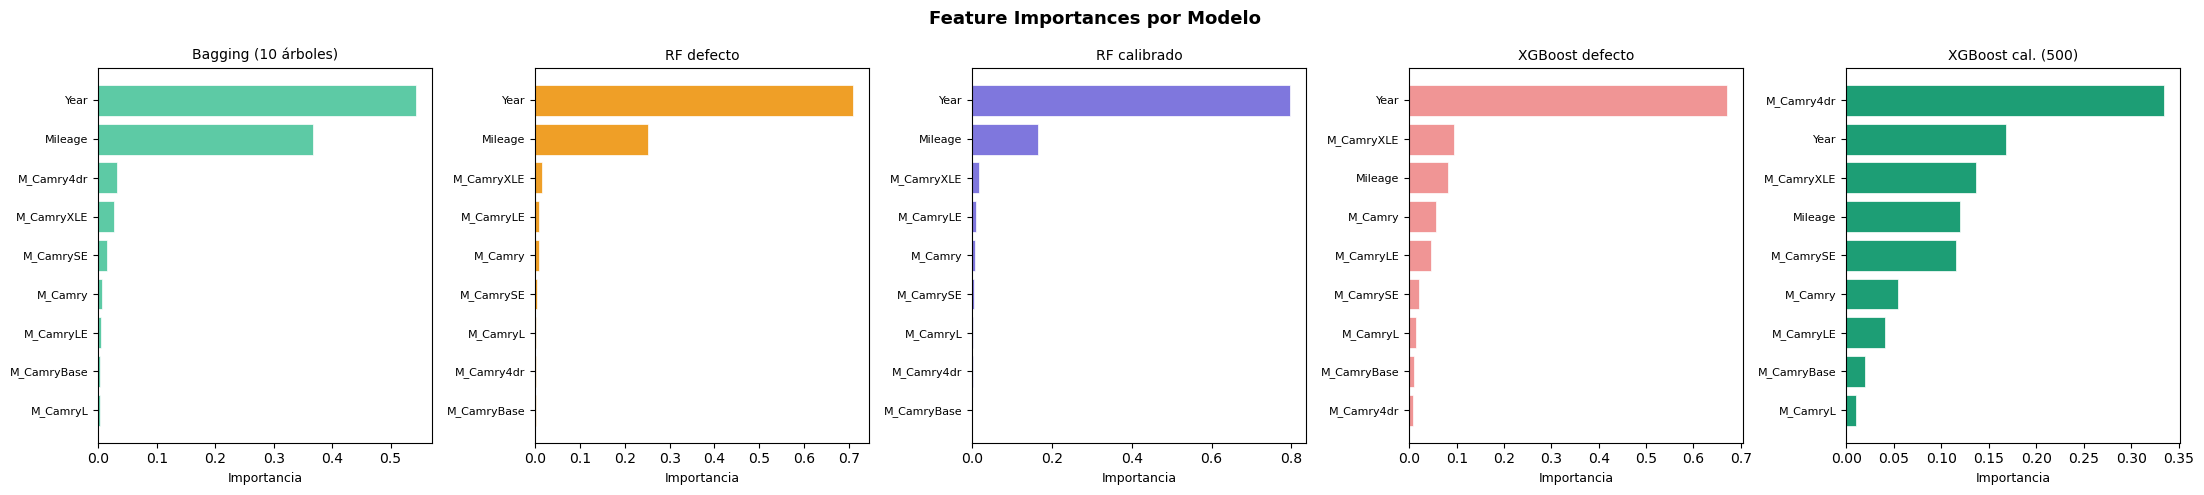

In [ ]:
# Feature Importances — modelos sklearn
feature_cols = X_train.columns.tolist()

# Bagging — promedio sobre estimators_ porque BaggingRegressor no tiene feature_importances_ directo
importances_b = np.mean([tree.feature_importances_ for tree in bagreg.estimators_], axis=0)

# DataFrames de importancias ordenadas
df_imp_b       = pd.DataFrame({'feature': feature_cols, 'importance': importances_b}).sort_values('importance', ascending=False)
df_imp_rf      = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
df_imp_rf_cal  = pd.DataFrame({'feature': feature_cols, 'importance': rf_final.feature_importances_}).sort_values('importance', ascending=False)
df_imp_xgb     = pd.DataFrame({'feature': feature_cols, 'importance': clf.feature_importances_}).sort_values('importance', ascending=False)
df_imp_xgb_cal = pd.DataFrame({'feature': feature_cols, 'importance': xgb_final_n.feature_importances_}).sort_values('importance', ascending=False)

# Visualización
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle("Feature Importances por Modelo", fontsize=13, fontweight='bold')

datos = [
    (df_imp_b,       "Bagging (10 árboles)",    "#5DCAA5"),
    (df_imp_rf,      "RF defecto",               "#EF9F27"),
    (df_imp_rf_cal,  "RF calibrado",             "#7F77DD"),
    (df_imp_xgb,     "XGBoost defecto",          "#F09595"),
    (df_imp_xgb_cal, "XGBoost cal. (500)",       "#1D9E75"),
]

for ax, (df, titulo, color) in zip(axes, datos):
    ax.barh(df['feature'], df['importance'], color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel("Importancia", fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

En resumen: RF confía casi exclusivamente en Year y Mileage para predecir el precio, mientras que XGBoost calibrado logra distribuir el aprendizaje entre más features, lo que parcialmente explica por qué alcanza el mejor R2 (0.8436), al capturar señales adicionales que RF descarta.